In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [ ]:
# Review top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Number of rows and columns
df.shape

(4000, 28)

In [ ]:
# Column names
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
# Data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [ ]:
# Data quality check
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [ ]:
# Missing values
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]

missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [ ]:
# Handling missing values
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [ ]:
# Check missing values again
df.isna().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
# Crop distribution
crop_counts = df['Crop'].value_counts()
crop_counts

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [ ]:
# Season distribution
season_counts = df['Season'].value_counts()
season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
# Irrigation methods
irrigation_counts = df['Irrigation_Method'].value_counts()
irrigation_counts

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## Univariate Analysis

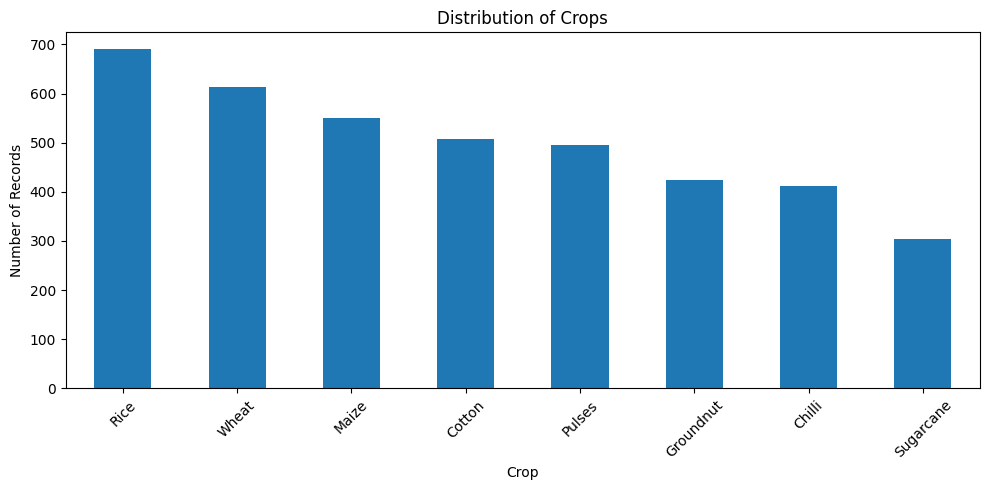

In [ ]:
plt.figure(figsize=(10, 5))
crop_counts.plot(kind='bar')
plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

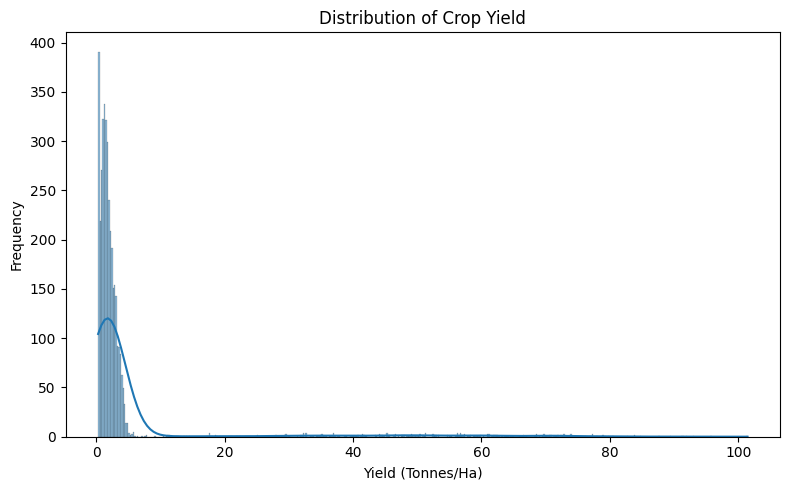

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Yield_Tonnes_Ha'], kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

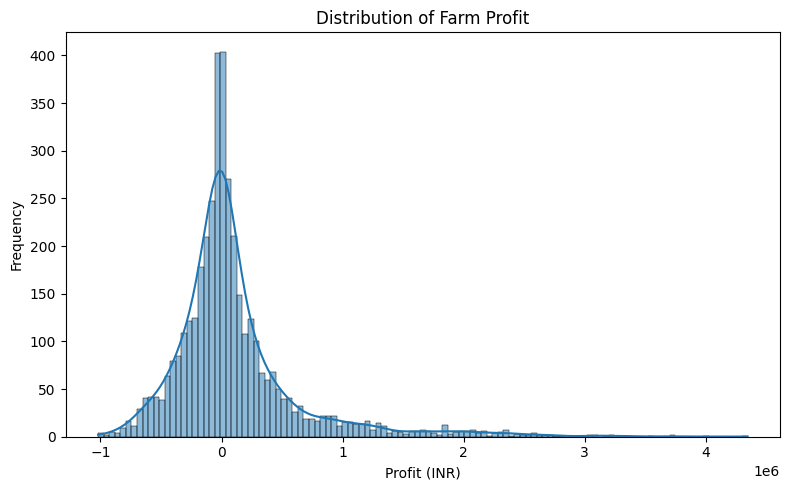

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Profit_INR'], kde=True)
plt.title('Distribution of Farm Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Outlier Investigation

In [ ]:
# Checking outliers
numeric_columns = df.select_dtypes(include=np.number).columns
outlier_counts = {}
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = (
        (df[col] < lower) | (df[col] > upper)
    ).sum()

outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_counts

,0
Profit_INR,404
Production_Tonnes,333
Water_Efficiency_t_per_1000m3,322
Yield_Tonnes_Ha,302
Water_Used_m3,276
Revenue_INR,240
Potassium_kg_ha,32
Sunlight_Hours_Day,26
Phosphorus_kg_ha,16
Fertilizer_kg_ha,15


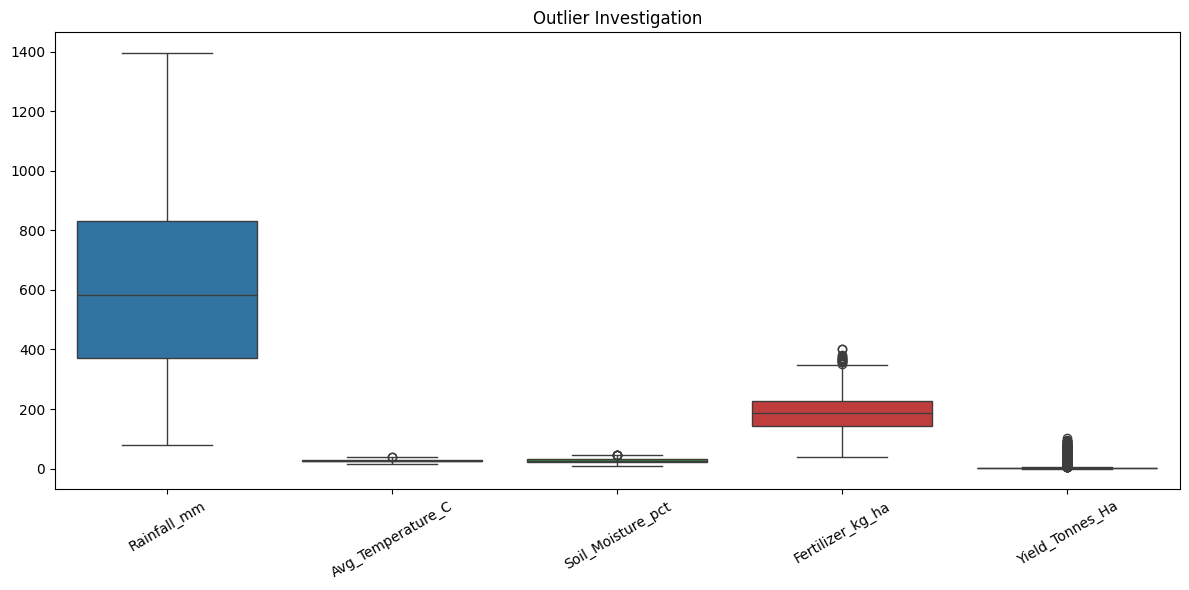

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[
        [
            'Rainfall_mm',
            'Avg_Temperature_C',
            'Soil_Moisture_pct',
            'Fertilizer_kg_ha',
            'Yield_Tonnes_Ha'
        ]
    ]
)

plt.title('Outlier Investigation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Bivariate Analysis

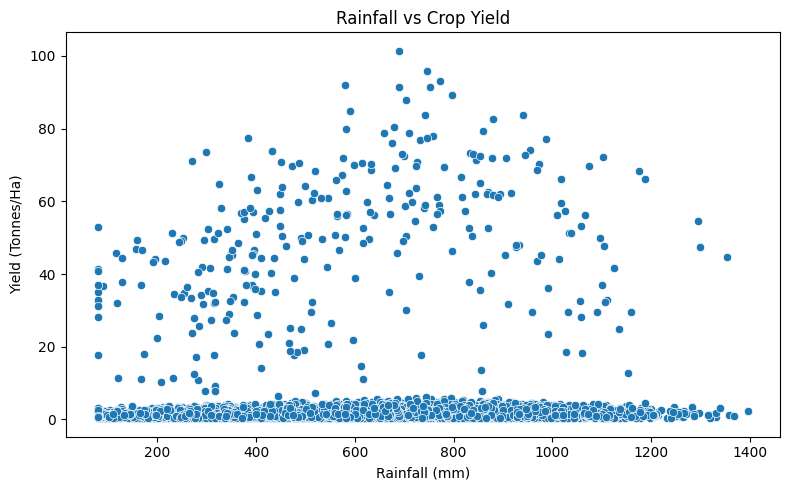

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

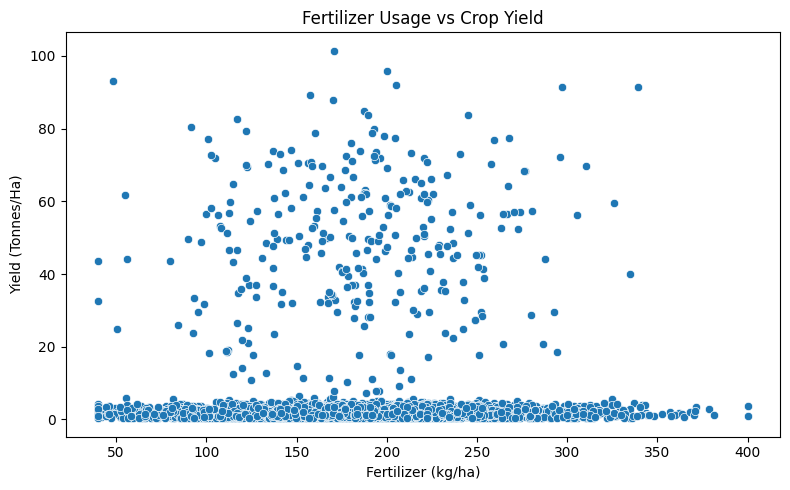

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha'
)
plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

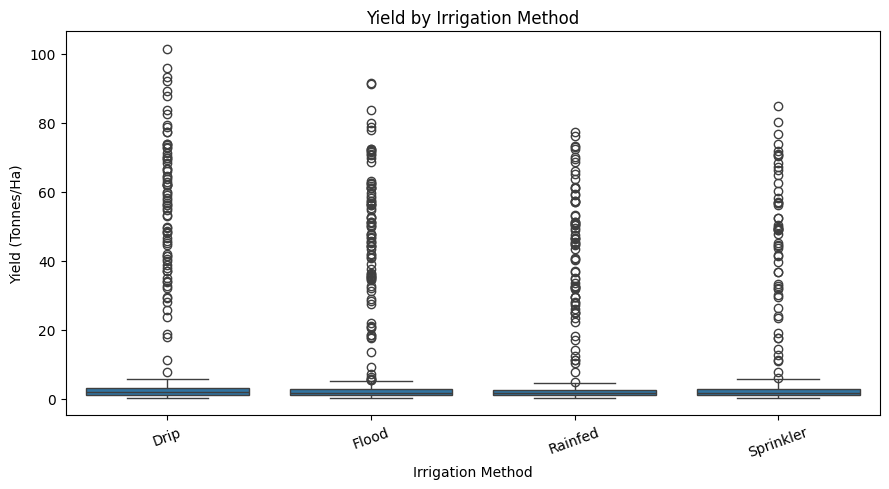

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha'
)
plt.title('Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Multivariate Analysis

In [ ]:
# Average yield by crop and season
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


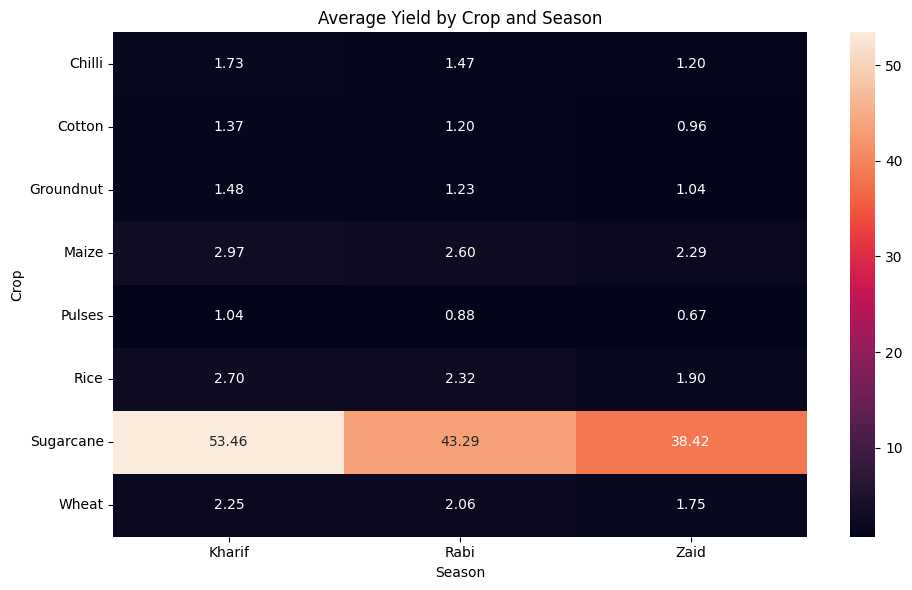

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)
plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

## Correlation Analysis

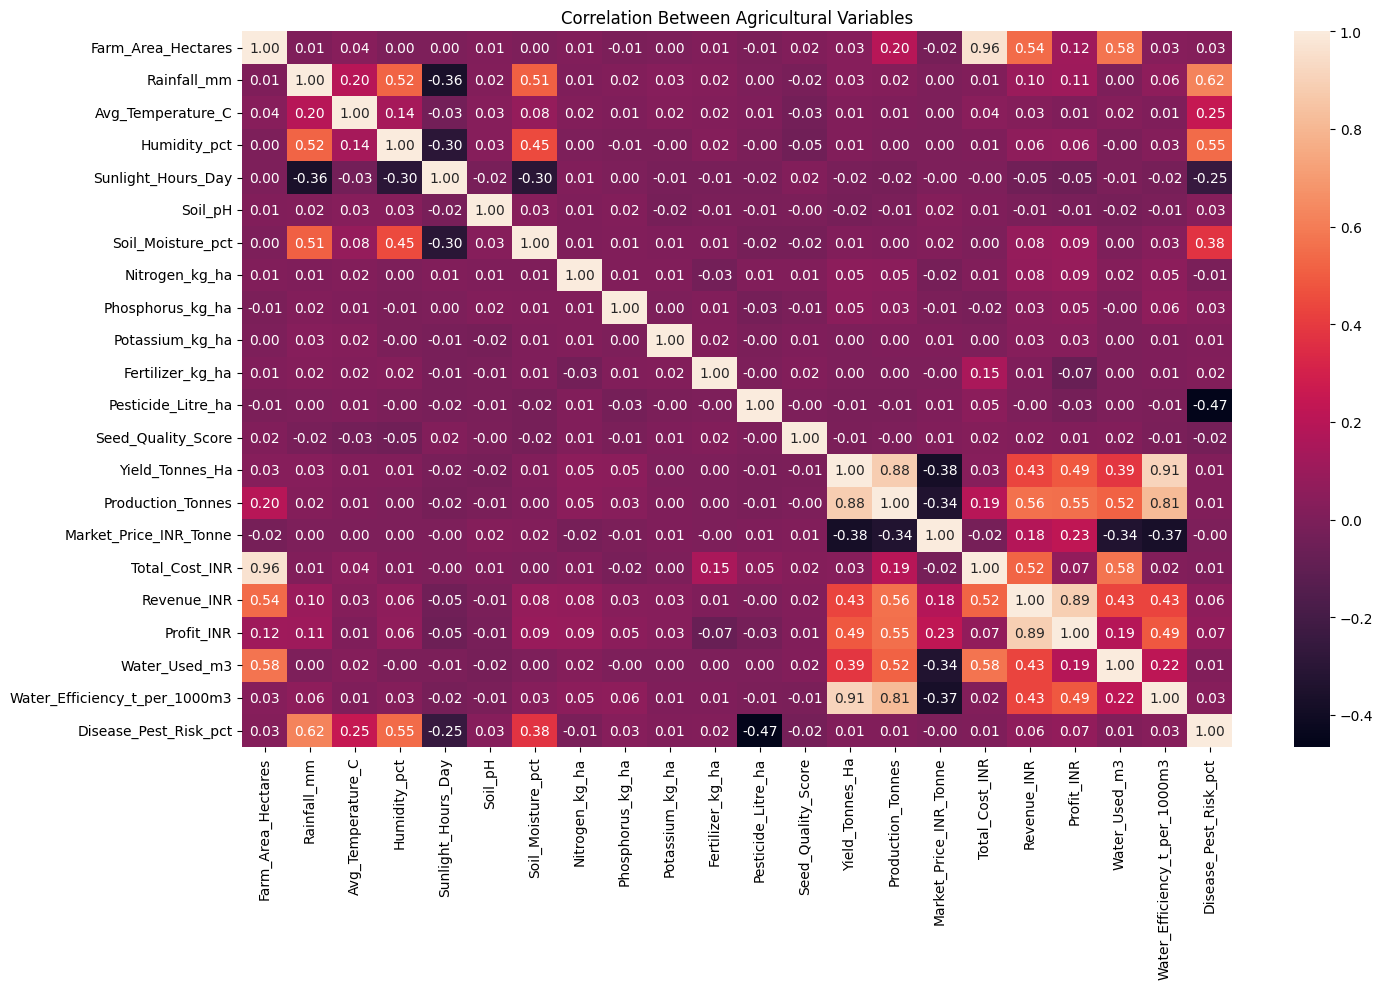

In [ ]:
# Correlation analysis
correlation = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Between Agricultural Variables')
plt.tight_layout()
plt.show()

In [ ]:
# Correlation with yield
correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
# Correlation with profit
correlation['Profit_INR'].sort_values(ascending=False)

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


## Seasonal Comparison

In [ ]:
# Average yield by season
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


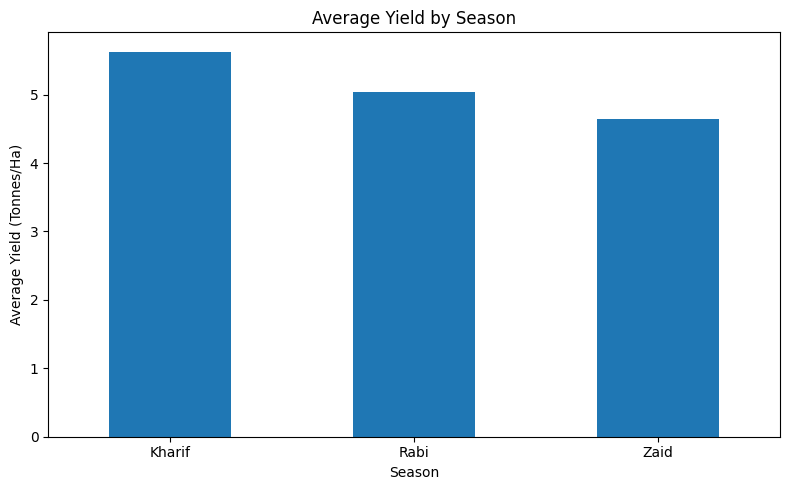

In [ ]:
plt.figure(figsize=(8, 5))
season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Average profit by season
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)
season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


## Student-Designed Analysis 1: Crop Performance

In [ ]:
# Crop performance
crop_performance = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).sort_values('Profit_INR', ascending=False)
crop_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Crop,,,,,
Sugarcane,46.642361,392.413016,1.371980e+06,554792.127869,817187.986885
Chilli,1.542767,12.382888,1.276777e+06,525898.885922,750878.342233
Cotton,1.229783,9.395866,6.394231e+05,514876.167323,124546.915354
Groundnut,1.322901,9.655825,5.429355e+05,498077.377358,44858.120283
Pulses,0.921512,7.401411,5.284659e+05,532703.919355,-4238.052419
Maize,2.710036,21.781125,4.570680e+05,541046.317604,-83978.326679
Rice,2.431304,19.288623,4.236153e+05,525828.763768,-102213.504348
Wheat,2.108013,16.853909,4.001049e+05,523503.223127,-123398.337134


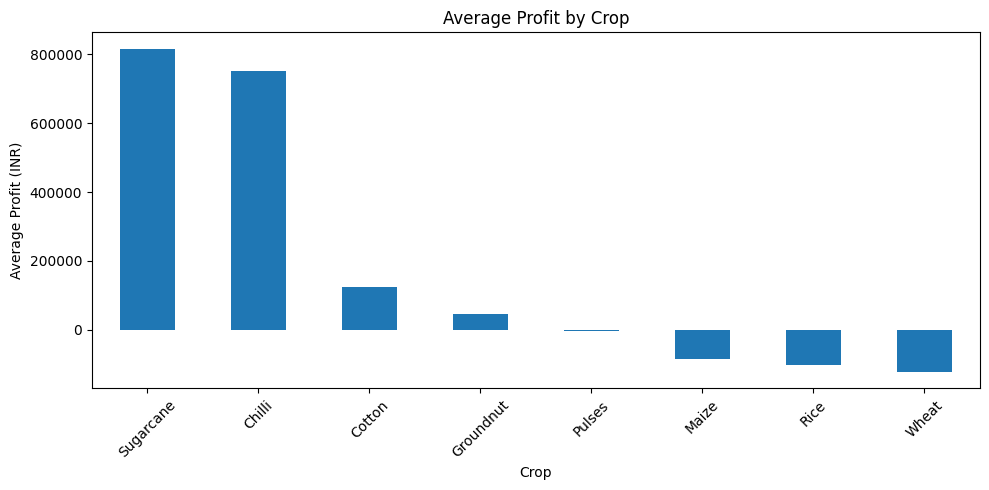

In [ ]:
plt.figure(figsize=(10, 5))
crop_performance['Profit_INR'].plot(kind='bar')
plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Student-Designed Analysis 2: Irrigation Efficiency

In [ ]:
# Irrigation performance
irrigation_analysis = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).sort_values(
    'Water_Efficiency_t_per_1000m3',
    ascending=False
)
irrigation_analysis

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Rainfed,4.602142,3549.554275,7.563784,79050.365034
Drip,6.577989,5918.747541,6.267129,219625.997814
Sprinkler,5.160627,6208.258856,4.669805,91121.079019
Flood,4.863977,8026.472519,3.438853,73354.022901


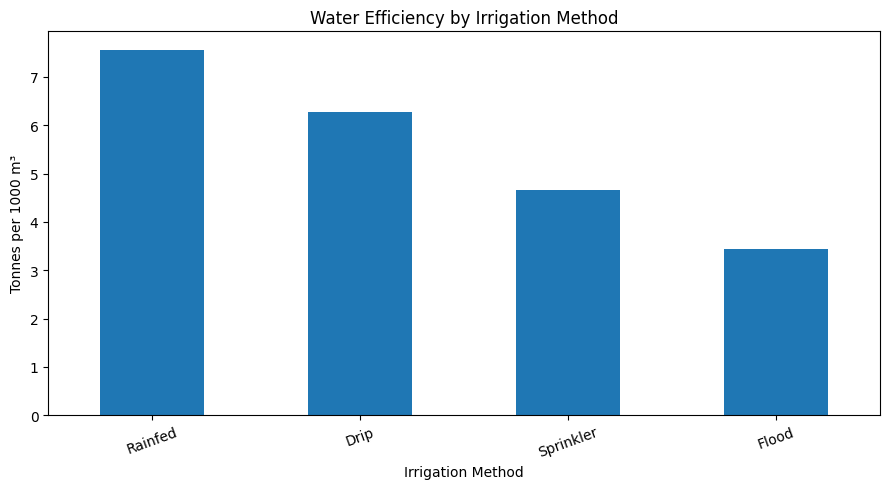

In [ ]:
plt.figure(figsize=(9, 5))
irrigation_analysis[
    'Water_Efficiency_t_per_1000m3'
].plot(kind='bar')
plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Tonnes per 1000 m³')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Student-Designed Analysis 3: Disease and Pest Risk

In [ ]:
# Disease and pest risk analysis
risk_analysis = df.groupby('Crop').agg({
    'Disease_Pest_Risk_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean'
}).sort_values(
    'Disease_Pest_Risk_pct',
    ascending=False
)
risk_analysis

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha,Profit_INR
Crop,,,
Wheat,47.854723,2.108013,-123398.337134
Pulses,46.570161,0.921512,-4238.052419
Rice,46.495797,2.431304,-102213.504348
Groundnut,46.289151,1.322901,44858.120283
Chilli,46.062136,1.542767,750878.342233
Cotton,45.974606,1.229783,124546.915354
Maize,45.539564,2.710036,-83978.326679
Sugarcane,45.403934,46.642361,817187.986885


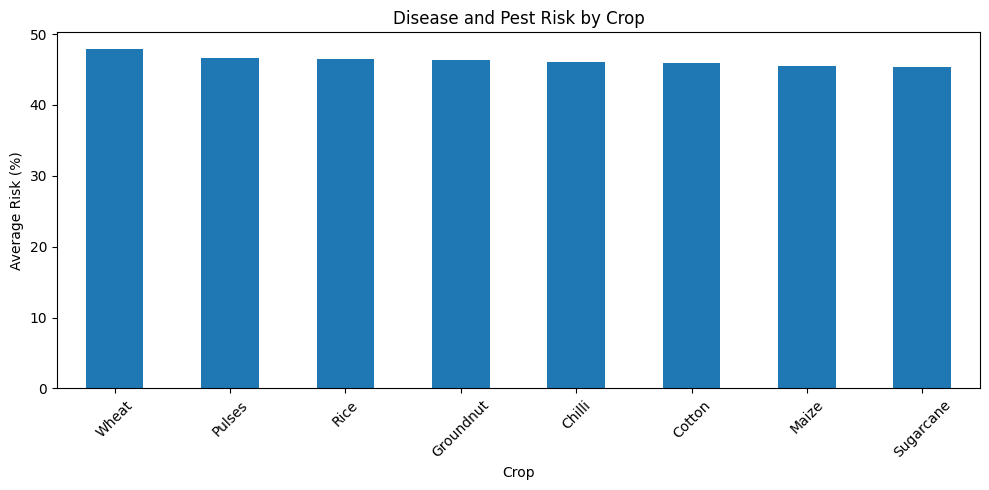

In [ ]:
plt.figure(figsize=(10, 5))
risk_analysis['Disease_Pest_Risk_pct'].plot(kind='bar')
plt.title('Disease and Pest Risk by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Risk (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Additional Analysis: Crop and Season Profitability

In [ ]:
crop_season_profit = df.groupby(
    ['Crop', 'Season']
)['Profit_INR'].mean().sort_values(ascending=False)
crop_season_profit.head(10)

,,Profit_INR
Crop,Season,
Sugarcane,Kharif,1.000791e+06
Chilli,Kharif,9.543804e+05
Sugarcane,Rabi,7.316129e+05
Chilli,Rabi,6.385725e+05
Sugarcane,Zaid,5.836358e+05
Chilli,Zaid,4.486591e+05
Cotton,Kharif,2.169995e+05
Groundnut,Kharif,1.082654e+05
Cotton,Rabi,1.073436e+05


## Key Insights

1. Kharif is the best-performing season in terms of average yield, with an average of 5.63 tonnes/ha.

2. Sugarcane has the highest yield among the crops, with particularly strong performance during the Kharif season.

3. Sugarcane during Kharif is the most profitable crop-season combination, with an average profit of around ₹10.01 lakh.

4. Chilli is also highly profitable, especially during Kharif, where its average profit is around ₹9.54 lakh.

5. Water efficiency has a very strong positive relationship with yield, with a correlation of 0.913.

6. Production and yield are strongly related, with a correlation of 0.883.

7. Revenue has a strong positive relationship with profit, with a correlation of 0.887.

8. Drip irrigation records the highest average yield among the irrigation methods, at around 6.58 tonnes/ha.

9. Rainfed farming shows the highest water efficiency at around 7.56 tonnes per 1,000 m³.

10. Market price has a negative correlation with yield (-0.383), suggesting that higher market prices do not necessarily correspond to higher yields in this dataset.

## Evidence-Based Recommendations

1. Give greater consideration to Kharif cultivation where local conditions are suitable, as it recorded the highest average yield of 5.63 tonnes/ha, compared with 5.04 tonnes/ha in Rabi and 4.64 tonnes/ha in Zaid.

2. Consider Sugarcane and Chilli for profitable cultivation, especially during Kharif. Sugarcane–Kharif recorded the highest average profit of approximately ₹10.01 lakh, while Chilli–Kharif recorded about ₹9.54 lakh.

3. Promote efficient irrigation practices such as drip irrigation where practical. Drip irrigation recorded the highest average yield among the irrigation methods at about 6.58 tonnes/ha.

4. Focus on improving water-use efficiency, since water efficiency had a strong positive correlation of 0.913 with yield.

5. Use crop and season combinations when planning cultivation rather than selecting crops independently of seasonal conditions.

6. Consider revenue and production when evaluating profitability, as revenue has a strong positive relationship with profit and production also shows a positive relationship with profit.

7. Monitor disease and pest risk regularly, particularly for crops showing relatively higher risk levels. Crop-specific monitoring can help in better planning and risk management.

8. Avoid judging irrigation methods only by yield. Rainfed farming showed high water efficiency, while Drip irrigation showed the highest average yield. Therefore, both productivity and water efficiency should be considered when selecting an irrigation method.

## Limitations

1. The dataset represents a limited set of agricultural observations, so the results may not represent farming conditions across all regions.

2. Some values were missing in variables such as rainfall, soil moisture and yield. These missing values were replaced using median values, which may have a small effect on the analysis.

3. Outliers were identified in some variables. These were investigated but not automatically removed because some extreme values may represent genuine agricultural conditions.

4. Correlation does not prove causation. For example, the strong relationship between water efficiency and yield does not by itself prove that improving water efficiency will directly cause higher yield.

5. The dataset does not include every factor that can affect agricultural performance. Other environmental, farming and economic factors may also influence yield and profitability.

6. Market prices and production costs can change over time, so profitability results may differ under different market conditions.

## Conclusion

The Seasonal Agriculture Performance dataset was analyzed to understand crop yield, production, profitability, irrigation, water efficiency and seasonal performance.

The analysis shows that Kharif had the highest average yield, while Sugarcane and Chilli showed particularly strong profitability, especially during the Kharif season.

The analysis also showed a strong relationship between water efficiency and yield, while revenue and production were important factors associated with profit. Drip irrigation recorded the highest average yield among the irrigation methods, while Rainfed farming showed high water efficiency.

Overall, the findings suggest that crop selection, seasonal planning, irrigation practices and efficient resource management are important when evaluating agricultural performance. These findings can support better cultivation and resource-planning decisions, while the limitations of the dataset should be considered before applying the results more broadly.

## Final Dashboard

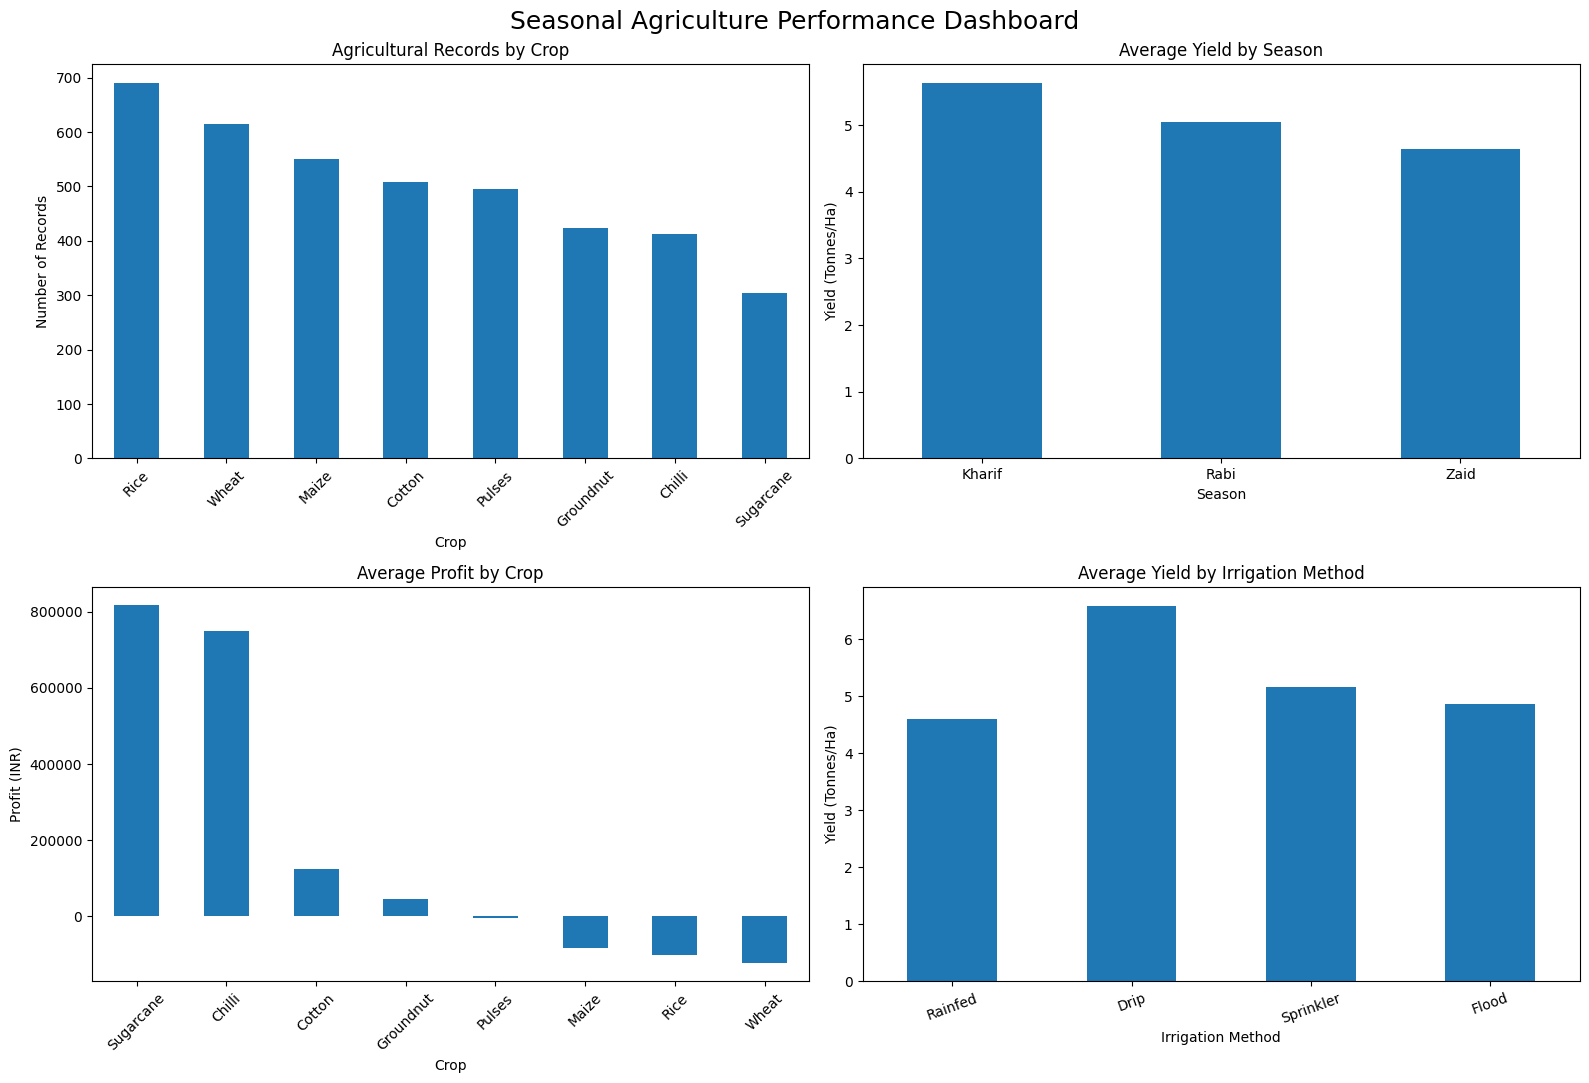

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Seasonal Agriculture Performance Dashboard',
    fontsize=18
)
# Crop distribution
crop_counts.plot(
    kind='bar',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Agricultural Records by Crop')
axes[0, 0].set_xlabel('Crop')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].tick_params(axis='x', rotation=45)
# Average yield by season
season_yield.plot(
    kind='bar',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average Yield by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Yield (Tonnes/Ha)')
axes[0, 1].tick_params(axis='x', rotation=0)
# Average profit by cro
crop_performance['Profit_INR'].plot(
    kind='bar',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Average Profit by Crop')
axes[1, 0].set_xlabel('Crop')
axes[1, 0].set_ylabel('Profit (INR)')
axes[1, 0].tick_params(axis='x', rotation=45)
# Yield by irrigation method
irrigation_analysis['Yield_Tonnes_Ha'].plot(
    kind='bar',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Average Yield by Irrigation Method')
axes[1, 1].set_xlabel('Irrigation Method')
axes[1, 1].set_ylabel('Yield (Tonnes/Ha)')
axes[1, 1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()